In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Kiểm tra tổng quan</h3>

In [ ]:
pharmacity_df = pd.read_csv("pharmacity_medicines_data_final.csv")
print(pharmacity_df.shape)
pharmacity_df.info()
pharmacity_df.head()

(3568, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3568 entries, 0 to 3567
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 3568 non-null   object 
 1   name                3552 non-null   object 
 2   price               1071 non-null   object 
 3   images              3560 non-null   object 
 4   nha_san_xuat        3369 non-null   object 
 5   noi_san_xuat        677 non-null    object 
 6   thuoc_can_ke_don    1180 non-null   object 
 7   hoat_chat           3089 non-null   object 
 8   chi_dinh_tom_tat    3042 non-null   object 
 9   dang_bao_che        3101 non-null   object 
 10  quy_cach            2983 non-null   object 
 11  luu_y               3053 non-null   object 
 12  mo_ta               1221 non-null   object 
 13  thanh_phan          2148 non-null   object 
 14  chi_dinh_chi_tiet   1472 non-null   object 
 15  huong_dan_su_dung   2135 non-null   object 


,url,name,price,images,nha_san_xuat,noi_san_xuat,thuoc_can_ke_don,hoat_chat,chi_dinh_tom_tat,dang_bao_che,...,chi_dinh_chi_tiet,huong_dan_su_dung,cach_su_dung,than_trong,thong_tin_san_xuat,category,drug_type,category_link,category_name,error
0,https://www.pharmacity.vn/vien-nen-postinor-1-...,Viên nén Postinor 1 (Hộp 1 viên) - Ngừa thai k...,40.000 ₫/Hộp,['https://prod-cdn.pharmacity.io/e-com/images/...,Gedeon Richter,Hungary,Không,LEVONORGESTREL,Thuốc tránh thai khẩn cấp trong vòng 72 giờ,Viên nén,...,Cách dùng viên nén Postinor 1\nCách dùng\nDùng...,"Tác dụng phụ\n\nKhi sử dụng thuốc Postinor 1, ...",NaN,Thông tin sản xuất\nBảo quản: Bảo quản nơi khô...,NaN,Thuốc ngừa thai,Thuốc không kê đơn,https://www.pharmacity.vn/thuoc-ngua-thai,Thuốc ngừa thai,NaN
1,https://www.pharmacity.vn/cerciorat-hop-1-vi-x...,Cerciorat Leon Farma (Hộp 1 vỉ x 1 viên) – Trá...,35.990 ₫/Hộp,['https://prod-cdn.pharmacity.io/e-com/images/...,EXELTIS PHARMA,Spain,Không,LEVONORGESTREL,Thuốc tránh thai khẩn cấp trong vòng 72 giờ,Viên nén,...,Liều dùng và cách dùng \nLiều dùng\n\nUống 1 v...,Thận trọng khi dùng thuốc\nChống chỉ định (Khi...,NaN,Thông tin sản xuất\nBảo quản: Ở nhiệt độ dưới ...,NaN,Thuốc ngừa thai,Thuốc không kê đơn,https://www.pharmacity.vn/thuoc-ngua-thai,Thuốc ngừa thai,NaN
2,https://www.pharmacity.vn/bocinor-tab-15mg-hop...,Viên nén BOCINOR 1.5MG thuốc tránh thai khẩn c...,9.500 ₫/Hộp,['https://prod-cdn.pharmacity.io/e-com/images/...,Ba Đình,NaN,NaN,LEVONORGESTREL,Thuốc tránh thai khẩn cấp trong vòng 72 giờ,Viên nén,...,Cách dùng Viên nén BOCINOR 1.5MG\nLiều dùng\n\...,Tác dụng phụ\nQuá liều và cách xử trí\n\nCác t...,NaN,"Thông tin sản xuất\nBảo quản: Nơi khô ráo, trá...",NaN,Thuốc ngừa thai,Thuốc không kê đơn,https://www.pharmacity.vn/thuoc-ngua-thai,Thuốc ngừa thai,NaN
3,https://www.pharmacity.vn/avalo-day-hop-28-vie...,Avalo day (Hộp 28 viên),25.000 ₫/Hộp,['https://prod-cdn.pharmacity.io/e-com/images/...,CT CP hóa dược VN,NaN,Không,Levonorgestrel,Thuốc tránh thai,Viên nén,...,NaN,Tác dụng phụ\nChống chỉ địnhMang thai hoặc ngh...,NaN,NaN,NaN,Thuốc ngừa thai,Thuốc không kê đơn,https://www.pharmacity.vn/thuoc-ngua-thai,Thuốc ngừa thai,NaN
4,https://www.pharmacity.vn/newlevo.html,Newlevo 0.03mg (1 vỉ x 28 viên),8.000 ₫/Hộp,['https://prod-cdn.pharmacity.io/e-com/images/...,Ba Dinh Pharma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Thuốc ngừa thai,Thuốc không kê đơn,https://www.pharmacity.vn/thuoc-ngua-thai,Thuốc ngừa thai,NaN


<h3>Kiểm tra giá trị thiếu<h3>

In [4]:
# Kiểm tra giá trị thiếu ở mỗi cột
missing_values = pharmacity_df.isna().sum()
print("Số lượng giá trị thiếu ở mỗi cột:")
print(missing_values)

# Kiểm tra giá trị thiếu (tính theo phần trăm)
missing_percentage = round((pharmacity_df.isna().sum() / len(pharmacity_df)) * 100, 2)
print("\nPhần trăm giá trị thiếu ở mỗi cột:")
print(missing_percentage)

Số lượng giá trị thiếu ở mỗi cột:
url                      0
name                    16
price                 2497
images                   8
nha_san_xuat           199
noi_san_xuat          2891
thuoc_can_ke_don      2388
hoat_chat              479
chi_dinh_tom_tat       526
dang_bao_che           467
quy_cach               585
luu_y                  515
mo_ta                 2347
thanh_phan            1420
chi_dinh_chi_tiet     2096
huong_dan_su_dung     1433
cach_su_dung          3560
than_trong            1939
thong_tin_san_xuat    3568
category               469
drug_type              469
category_link          469
category_name            0
error                 3099
dtype: int64

Phần trăm giá trị thiếu ở mỗi cột:
url                     0.00
name                    0.45
price                  69.98
images                  0.22
nha_san_xuat            5.58
noi_san_xuat           81.03
thuoc_can_ke_don       66.93
hoat_chat              13.42
chi_dinh_tom_tat       14.74
dang_bao

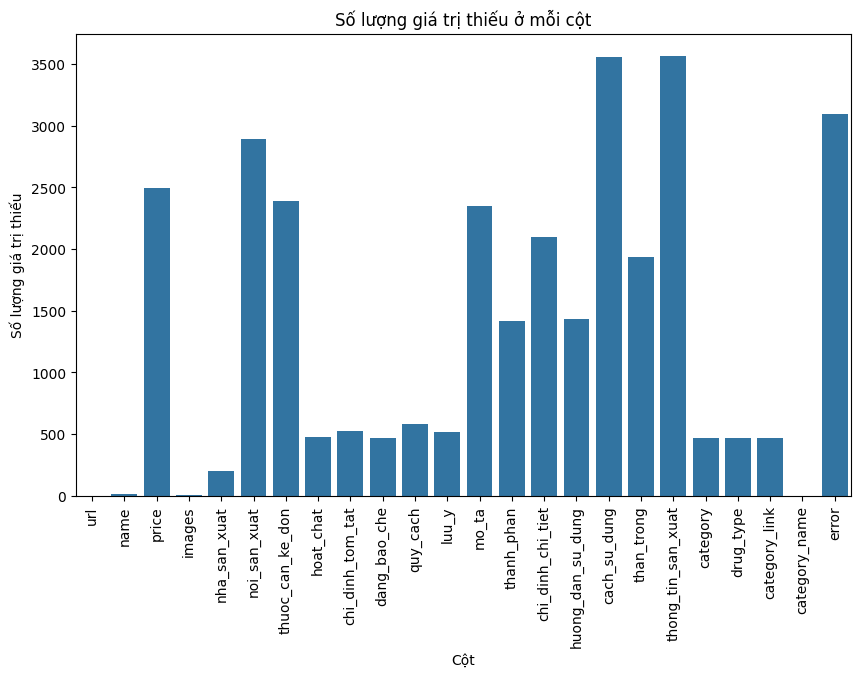

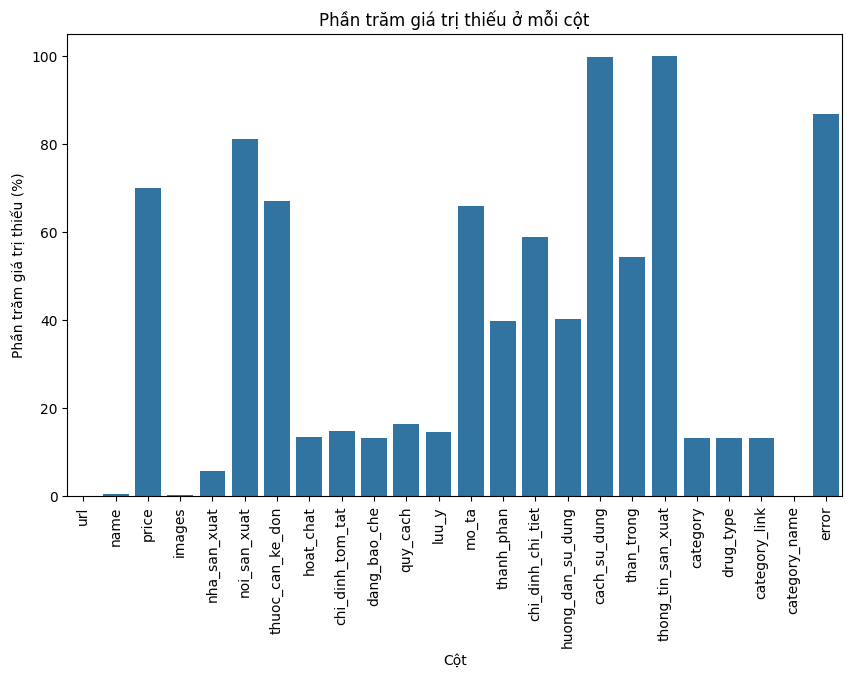

In [6]:
# Vẽ biểu đồ giá trị thiếu theo cột (theo số lượng)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=90)
plt.title("Số lượng giá trị thiếu ở mỗi cột")
plt.xlabel("Cột")
plt.ylabel("Số lượng giá trị thiếu")
plt.show()


# Vẽ biểu đồ giá trị thiếu theo cột (theo phần trăm)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
plt.xticks(rotation=90)
plt.title("Phần trăm giá trị thiếu ở mỗi cột")
plt.xlabel("Cột")
plt.ylabel("Phần trăm giá trị thiếu (%)")
plt.show()

<h3>Kiểm tra giá trị trùng lặp</h3>

In [7]:
# Kiểm tra giá trị trùng lặp
duplicate_count = pharmacity_df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")


Số lượng dòng trùng lặp: 0


<h3>Kiểm tra phân bố nhãn</h3>

Số lượng bệnh theo category:
category_name
Thuốc tiêu hóa              574
Thuốc kháng sinh            319
Thuốc cơ xương khớp         319
Thuốc da liễu               291
Vitamin & Khoáng chất       261
Thuốc Mắt/Tai/Mũi           206
Thuốc tiểu đường            205
Thuốc cảm lạnh              144
Thuốc kháng viêm            143
Hệ hô hấp                   142
Thuốc tim mạch, huyết áp    110
Thuốc kháng dị ứng          107
Giảm đau, hạ sốt            103
Thuốc cảm lạnh, ho           83
Thuốc dành cho nữ            82
Thuốc khác                   74
Thuốc ung thư                69
Kháng dị ứng                 52
Thuốc cho nam giới           48
Dầu, Cao xoa bóp...          43
Thuốc giảm đau, hạ sốt       37
Thuốc ngừa thai              36
Thuốc thần kinh              32
Vitamin khoáng chất          26
Thuốc dành cho phụ nữ        23
Thuốc tiết niệu              20
Thuốc dành cho nam            7
Thuốc giảm cân                4
Thuốc nhỏ mắt                 3
Dung dịch vệ sinh phụ nữ     

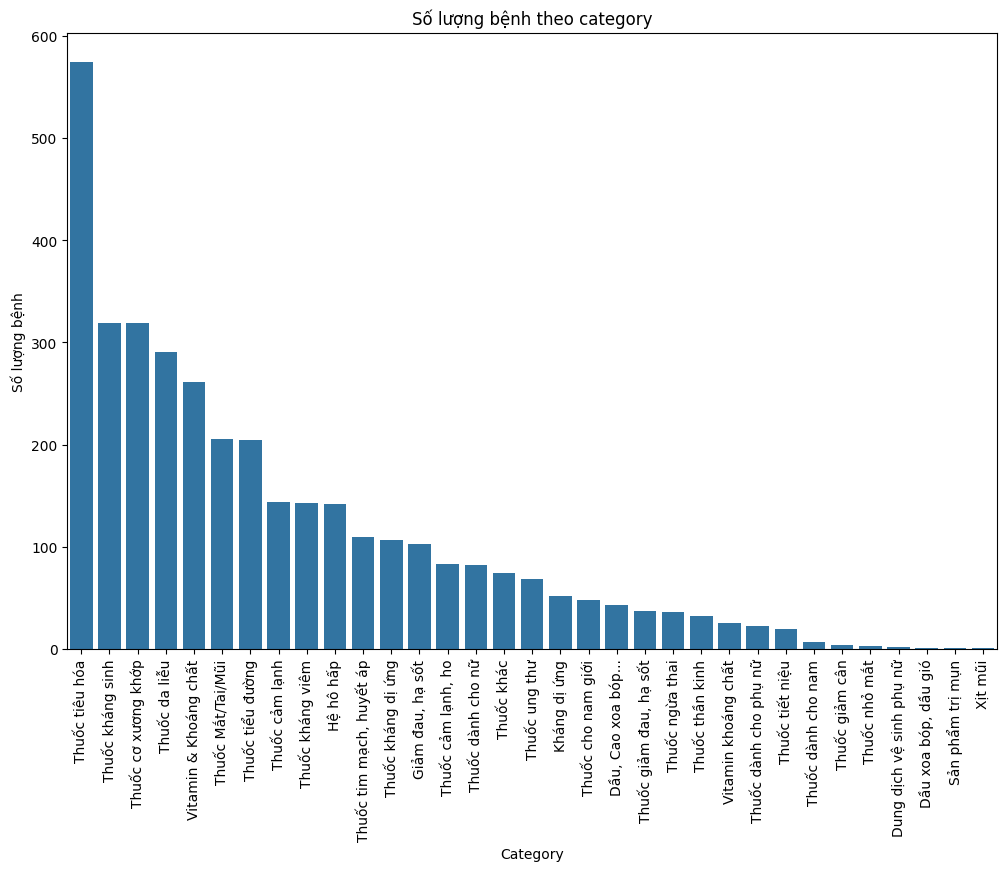

In [8]:
# Kiểm tra số lượng bệnh theo category
category_counts = pharmacity_df['category_name'].value_counts()
print("Số lượng bệnh theo category:")
print(category_counts)

# Vẽ biểu đồ số lượng bệnh theo category
plt.figure(figsize=(12, 8))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=90)
plt.title("Số lượng bệnh theo category")
plt.xlabel("Category")
plt.ylabel("Số lượng bệnh")
plt.show()